Данные онлайн магазина спортивных товаров: одежды, обуви, аксессуаров и спорт-питания. На главной странице магазина показываются пользователям баннеры с целью стимулирования своих продаж. Сейчас там случайно показывается один из 5 баннеров. Каждый баннер рекламирует конкретный продукт или всю компанию. Маркетологи считают, что опыт взаимодействия с баннерами может различаться по сегментам, а их эффективность - зависеть от особенностей пользовательского поведения.
У менеджера компании появилось предложение от партнеров: продать это место для баннера и рекламировать там другой сервис (оплата предполагается по CPC-модели, т.е. стоимость за клик), нужно ли продавать место для рекламы другого сервиса.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

Для начала были установлены нужные библиотеки для анализа данных

In [ ]:
df = pd.read_csv('ha_data.csv', delimiter=';')
print(df.head())

   order_id     page_id   product site_version                 time  \
0       NaN         3.0   company       mobile  2017-02-09 20:24:04   
1       NaN   3699687.0   company       mobile  2017-02-07 10:03:07   
2       NaN        14.0  sneakers       mobile  2017-01-29 13:02:23   
3       NaN  10362176.0   company       mobile  2017-04-12 15:39:19   
4       NaN        14.0  sneakers       mobile  2017-01-29 13:04:42   

          title    user  
0   banner_show  user_0  
1   banner_show  user_0  
2   banner_show  user_1  
3   banner_show  user_1  
4  banner_click  user_1  


df

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8471226 entries, 0 to 8471225
Data columns (total 8 columns):
 #   Column        Dtype         
---  ------        -----         
 0   order_id      float64       
 1   page_id       float64       
 2   product       object        
 3   site_version  object        
 4   time          datetime64[ns]
 5   title         object        
 6   user          object        
 7   date          object        
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 517.0+ MB


По типу данных становится понятно, что числовыми являются только id заказов и показов/кликов баннеров

In [ ]:
print(df.head(10))

   order_id     page_id           product site_version                time  \
0       NaN         3.0           company       mobile 2017-02-09 20:24:04   
1       NaN   3699687.0           company       mobile 2017-02-07 10:03:07   
2       NaN        14.0          sneakers       mobile 2017-01-29 13:02:23   
3       NaN  10362176.0           company       mobile 2017-04-12 15:39:19   
4       NaN        14.0          sneakers       mobile 2017-01-29 13:04:42   
5       NaN        18.0          sneakers      desktop 2017-01-11 09:22:12   
6       NaN        18.0          sneakers      desktop 2017-01-11 09:24:43   
7       NaN        26.0          sneakers      desktop 2017-01-09 09:38:51   
8       NaN   2004233.0  sports_nutrition      desktop 2017-01-09 09:12:45   
9       NaN   6323332.0           company      desktop 2017-01-03 08:58:18   

          title    user        date  
0   banner_show  user_0  2017-02-09  
1   banner_show  user_0  2017-02-07  
2   banner_show  user_1  20

In [ ]:
display(df.describe(include='all'))

,order_id,page_id,product,site_version,time,title,user,date
count,248722.000000,8.222504e+06,8471226,8471226,8471226,8471226,8471226,8471226
unique,NaN,NaN,5,2,NaN,3,4254621,151
top,NaN,NaN,clothes,mobile,NaN,banner_show,user_1934035,2017-05-20
freq,NaN,NaN,1786438,6088340,NaN,7393319,23,80025
mean,419014.864881,1.266396e+07,NaN,NaN,2017-03-24 09:10:40.759827200,NaN,NaN,NaN
min,1.000000,3.000000e+00,NaN,NaN,2017-01-01 00:00:03,NaN,NaN,NaN
25%,249551.500000,6.379249e+06,NaN,NaN,2017-02-15 12:19:33.249999872,NaN,NaN,NaN
50%,411646.000000,1.279075e+07,NaN,NaN,2017-03-29 15:16:17.500000,NaN,NaN,NaN
75%,580734.500000,1.896197e+07,NaN,NaN,2017-05-01 07:23:00,NaN,NaN,NaN
max,855750.000000,2.489722e+07,NaN,NaN,2017-05-31 23:59:58,NaN,NaN,NaN


По описательным статистикам можео сделать следующие выводы: по столбцу order_id - общее количество покупок 248 722. При этом количество событий page_id, то есть показы и отклики более 8,2 млн. Уникальных значений по столбцу product - 5, подтверждается, что ровно как и сказано в тз. Самый частный баннер, который показывается, баннер с одеждой (clothes) - более 1,78 миллионов раз. Названий событий title - 3, что тоже подтверждается о ровном количестве событий, больше всего событий по просмотру баннеров - 7 393 319 раз. Больше всего пользуются мобильной версией сайта - 71,9 % пользователей. Уникальных пользователей 4,25 миллионов, а самый активный пользователь совершил какое-либо действие 23 раза.

In [ ]:
print(df.isnull().sum())

order_id        8222504
page_id          248722
product               0
site_version          0
time                  0
title                 0
user                  0
date                  0
dtype: int64


Нулевые значения есть только в order_id и page_id по условию, в других столбцах нулевые значения отсутствуют

In [ ]:
df['time'] = pd.to_datetime(df['time'])

In [ ]:
all_titles = df['title'].unique()
print("\nВсе уникальные названия событий:")
for title in all_titles:
    print(f"'{title}'")


Все уникальные названия событий:
'banner_show'
'banner_click'
'order'


Так как были не понятны называния событий, этот код их показывает. Итого у нас есть 3 уникальных названия события для дальнейшего разделения на группы

In [ ]:
impressions = df[df['title'] == 'banner_show']
clicks = df[df['title'] == 'banner_click']
order = df[df['title'] == 'order']

In [ ]:
print(f"\nКоличество показов: {len(impressions)}")
print(f"Количество кликов: {len(clicks)}")
print(f"Количество покупок: {len(order)}")


Количество показов: 7393319
Количество кликов: 829185
Количество покупок: 248722


Данный код разбивает исходный датафрейм на три отдельных в зависимости от названия события: показы баннеров, клики по баннерам, покупка

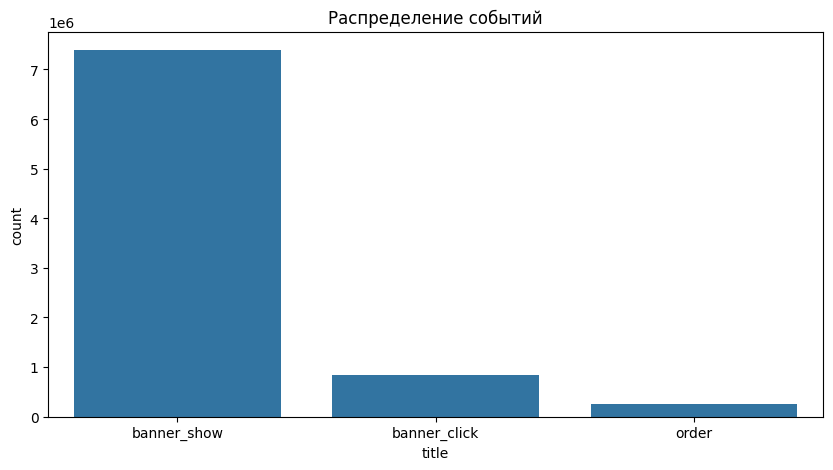

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='title')
plt.title('Распределение событий')
plt.show()

График показывает закономерное уменьшение событий, большинство пользователей только смотрят баннеры, после чего меньшинство заказывают этот товар. В дальнейшем будет подсчитана воронка конверсий для определения соотношений событий.

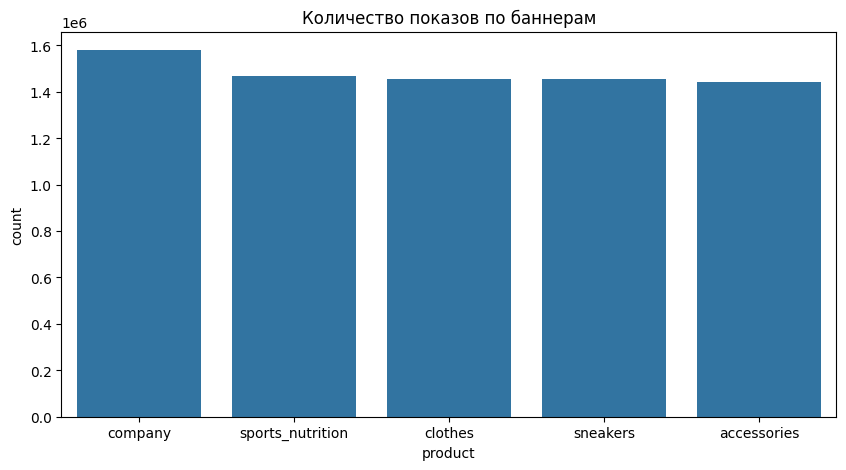

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=impressions, x='product', order=impressions['product'].value_counts().index)
plt.title('Количество показов по баннерам')
plt.show()

По событию количество показов баннеров, больше всего показывается баннеры о всей компании и примерно одинаковое количество показов имеют остальные баннеры по одежде, спортивному питанию, кроссовкам и акссесуарам.

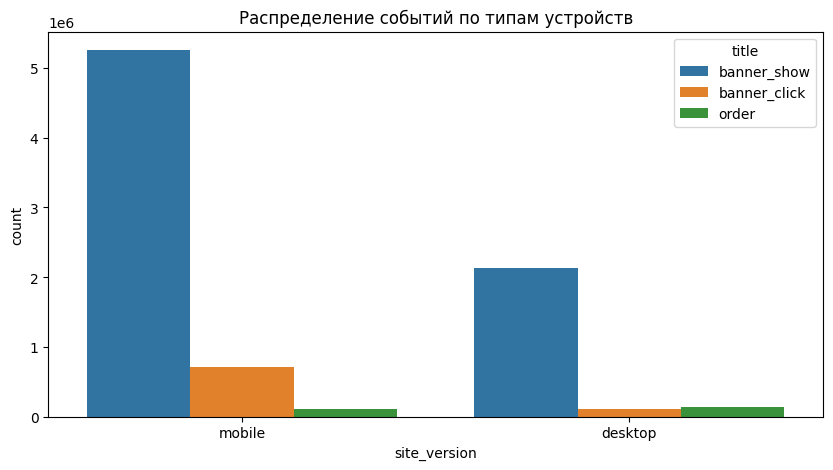

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='site_version', hue='title')
plt.title('Распределение событий по типам устройств')
plt.show()

По графику распределений по типам устройств и с мобильной версией, и с десктопной версии приложения больше всего событий по просмотрам баннеров. С десктопной версии пользователи больше делают заказов, чем кликают на баннер. Возможно это связано с тем, что пользователи с десктопной версией заходят на сайт за конкретным товаром и в меньшей степени обращают внимание на рекламу, чем пользователи мобильного приложения.

In [ ]:
impressions_by_banner = impressions.groupby('product').agg({'user': 'count'}).rename(columns={'user': 'impressions'})

Здесь данные были сгруппированы по показам и по названию баннера, а также для каждой группы посчитано количество уникальных пользователей

In [ ]:
clicks_by_banner = clicks.groupby('product').agg({'user': 'count'}).rename(columns={'user': 'clicks'})

Аналогично шагу выше сгруппированы данные по кликам и названию баннера

In [ ]:
banner_stats = impressions_by_banner.join(clicks_by_banner, how='left').fillna(0)
banner_stats['ctr'] = (banner_stats['clicks'] / banner_stats['impressions'] * 100).round(2)

В этом коде объединяются данные о показах и кликах по баннерам, пропущенные значения заменяются на 0, если баннер был показан, но не было клика по нему. Во втором шаге рассчитывается метрика CTR (Click Through Rate) - процент кликов от показа.

In [ ]:
clicked_users = clicks[['user', 'product', 'time']].rename(columns={'time': 'click_time'})
order_data = order[['user', 'product', 'time', 'order_id']].rename(columns={'time': 'order_time'})
print(clicked_users)
print(order_data)

                 user           product          click_time
4              user_1          sneakers 2017-01-29 13:04:42
6              user_2          sneakers 2017-01-11 09:24:43
10             user_3           company 2017-01-03 08:59:15
36             user_9  sports_nutrition 2017-02-04 03:18:45
37             user_9          sneakers 2017-01-21 21:00:42
...               ...               ...                 ...
8471178  user_4254584           company 2017-05-20 19:02:48
8471189  user_4254592           clothes 2017-05-25 19:27:05
8471193  user_4254594           clothes 2017-05-25 04:29:01
8471203  user_4254601       accessories 2017-05-29 08:33:55
8471220  user_4254615       accessories 2017-05-26 13:21:04

[829185 rows x 3 columns]
                 user           product          order_time  order_id
66            user_21  sports_nutrition 2017-03-03 10:15:41  504623.0
112           user_35          sneakers 2017-02-08 21:16:48  463510.0
113           user_35           clothes 201

Создается новый датафрейм только с нужными колонками

In [ ]:
merged_data = pd.merge(clicked_users, order_data, on=['user', 'product'], how='left')

Здесь объединяются данные по двум ключам: пользователю и виду баннера, то есть только те случаи, когда пользователь кликнул на баннер с определенным товаром и потом его купил

In [ ]:
merged_data['time_diff'] = (merged_data['order_time'] - merged_data['click_time']).dt.total_seconds() / 3600
merged_data['converted'] = merged_data['time_diff'].notna() & (merged_data['time_diff'] <= 48)

В этом шаге рассчитывается разница между кликом и покупкой в часах. Если разница между кликом и покупкой меньше или равна 48 часам и если покупка произошла, то считается, что покупка конвертировалась из клика.

In [ ]:
conversions_by_banner = merged_data.groupby('product')['converted'].sum().reset_index().rename(columns={'converted': 'conversions'})

Здесь группируются данные по баннерам и подсчитываются количество конверсий для каждого баннера

In [ ]:
banner_stats = banner_stats.join(conversions_by_banner.set_index('product'), how='left').fillna(0)
banner_stats['cvr'] = (banner_stats['conversions'] / banner_stats['clicks'] * 100).round(2)

Расчет CVR (Conversation Rate) - процент кликов, которые привели к покупке, является одной из ключевых метрик бизнес - эффективности

In [ ]:
print(banner_stats)

                  impressions  clicks    ctr  conversions   cvr
product                                                        
accessories           1440954  136254   9.46         2427  1.78
clothes               1453128  220595  15.18         8042  3.65
company               1580238  144821   9.16            0  0.00
sneakers              1453029  182597  12.57         4590  2.51
sports_nutrition      1465970  144918   9.89         1316  0.91


Таким образом, ключевые метрики, которые использовались в анализе - CTR (насколько привлекателен баннер) и CVR (эффективность баннера). Наибольший CTR по баннеру с одеждой (clothes) 15.18% кликов пользователей после просмотра, хороший показатель привлекательности также у баннера с кроссовками (sneakers) 12.57%. Если рассматривать конверсию с покупок, то лидер в баннерах также является одежда (clothes) 3.65% покупок после клика баннера и кроссовки (sneakers) 2.51% покупок. По баннеру компании CVR равен 0, так как это общая реклама для кликов, не для продажи.

Text(0.5, 0, 'Баннер')

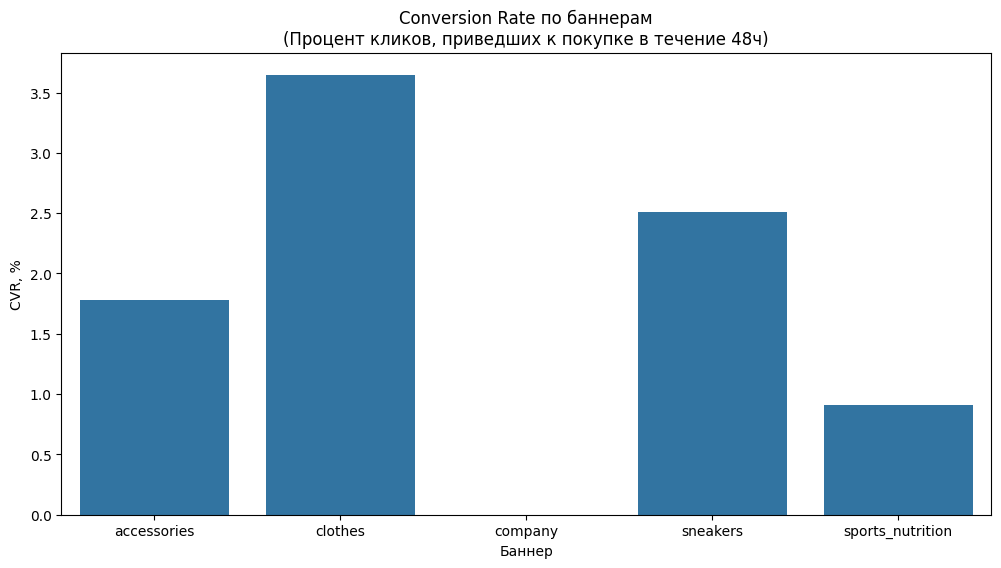

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=banner_stats.index, y='cvr', data=banner_stats.reset_index(), order=banner_stats.index)
plt.title('Conversion Rate по баннерам\n(Процент кликов, приведших к покупке в течение 48ч)')
plt.ylabel('CVR, %')
plt.xlabel('Баннер')

In [ ]:
clicked_users_with_device = clicks[['user', 'product', 'time', 'site_version']].copy()
clicked_users_with_device = clicked_users_with_device.rename(columns={'time': 'click_time'})

Следующий анализ конверсии в разрезе вида устройств

In [ ]:
merged_data_with_device = pd.merge(clicked_users_with_device, order_data, on=['user', 'product'], how='left')
merged_data_with_device['time_diff_hours'] = (merged_data_with_device['order_time'] - merged_data_with_device['click_time']).dt.total_seconds() / 3600
merged_data_with_device['converted'] = merged_data_with_device['time_diff_hours'].notna() & (merged_data_with_device['time_diff_hours'] <= 48) & (merged_data_with_device['time_diff_hours'] >= 0)

Здесь происходит объединение по пользователю и продукту, чтобы понять какие клики привели к покупкам и рассчитывается разница между кликом и покупкой, считаем, что разница может быть не более 48 часов

In [ ]:
device_banner_stats = merged_data_with_device.groupby(['site_version', 'product']).agg(
    clicks=('user', 'count'),
    conversions=('converted', 'sum')
).reset_index()

На этом шаге группируем данные по устройствам и баннерам и считается количество конверсий

In [ ]:
device_banner_stats['CTR (%)'] = 0
device_banner_stats['CVR (%)'] = (device_banner_stats['conversions'] / device_banner_stats['clicks'] * 100).round(3)

Расчет Conversation Rate

In [ ]:
impressions_by_device_banner = impressions.groupby(['site_version', 'product']).size().reset_index(name='impressions')
device_banner_stats = pd.merge(device_banner_stats, impressions_by_device_banner, on=['site_version', 'product'])
device_banner_stats['CTR (%)'] = (device_banner_stats['clicks'] / device_banner_stats['impressions'] * 100).round(3)

Добавление данных о показах баннеров для расчета CTR с комбинацией устройство и баннер

In [ ]:
print(device_banner_stats)

  site_version           product  clicks  conversions  CTR (%)  CVR (%)  \
0      desktop       accessories   18609           54    4.539    0.290   
1      desktop           clothes   33236          202    7.950    0.608   
2      desktop           company   28464            0    5.963    0.000   
3      desktop          sneakers   21548           86    5.235    0.399   
4      desktop  sports_nutrition   13886           26    3.325    0.187   
5       mobile       accessories  117750          108   11.421    0.092   
6       mobile           clothes  187976          317   18.161    0.169   
7       mobile           company  116357            0   10.550    0.000   
8       mobile          sneakers  161271          210   15.486    0.130   
9       mobile  sports_nutrition  131058           67   12.501    0.051   

   impressions  
0       410003  
1       418070  
2       477374  
3       411598  
4       417595  
5      1030951  
6      1035058  
7      1102864  
8      1041431  
9   

Как и было видно по графику ранее, мобильные устройства лидируют как по показам, так и по кликам. Показатель CTR, который показывает конверсию кликов по показам в 2,5 раза выше в мобильной версии (13.62% среднее), чем в десктопной версии(5.4%), что связано с более обдуманными рещениями или покупкой чего-то конкретного. Но если сравнивать показатель CVR, то десктоп пользователи в среднем совершают покупки после кликов 0.30%, а с мобильной версии в среднем только на 0.09%, что может быть связано с удобством заказов именно с desktop версии, импульсивными или случайными кликами в мобильной версии. В случае разреза данных по устройствам банееры с одеждой все также больше привлекают пользователей, как по кликам в мобильной версии (18.6%) и десктопной (7.95%), так и по заказам 0.169% и 0.608% соответсвенно. Хорошие показатели также по кроссовкам (sneakers). Значительный трафик на баннерах с компанией в целом, но конверсия в покупки нулевая, что является проблемной зоной. Проблемная зона как было сказано ранее и в показатели Conversation rate мобильной версии.

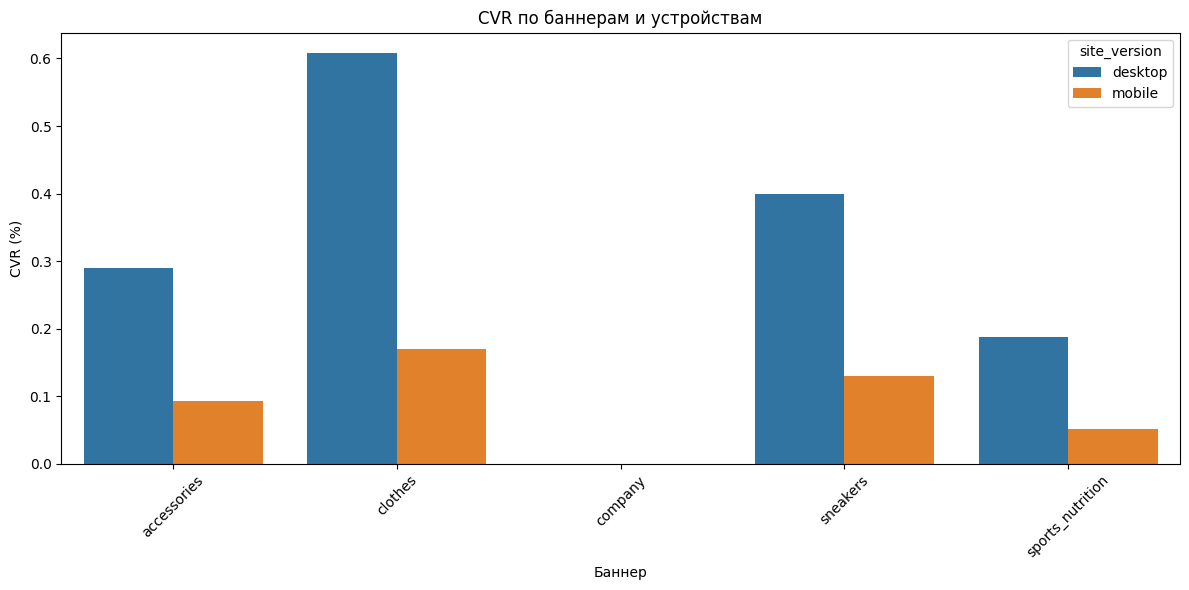

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=device_banner_stats, x='product', y='CVR (%)', hue='site_version')
plt.title('CVR по баннерам и устройствам')
plt.ylabel('CVR (%)')
plt.xlabel('Баннер')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import chi2_contingency
mobile_total = device_banner_stats[device_banner_stats['site_version'] == 'mobile'].sum()
desktop_total = device_banner_stats[device_banner_stats['site_version'] == 'desktop'].sum()

Для более точного анализа проверим статистическую значимость различий между мобильной и десктопной версией
Суммируем данные по всем баннерам для каждого устройства

In [ ]:
mobile_cvr_total = (mobile_total['conversions'] / mobile_total['clicks'] * 100).round(3)
desktop_cvr_total = (desktop_total['conversions'] / desktop_total['clicks'] * 100).round(3)

Рассчитываем CVR общие по мобильной и десктопной версии

In [ ]:
contingency_table_total = [
    [mobile_total['conversions'], mobile_total['clicks'] - mobile_total['conversions']],
    [desktop_total['conversions'], desktop_total['clicks'] - desktop_total['conversions']]
]

chi2_total, p_value_total, _, _ = chi2_contingency(contingency_table_total)

In [ ]:
print(f"Хи-квадрат: {chi2_total:.2f}")
print(f"p-value: {p_value_total:.10f}")

Хи-квадрат: 371.73
p-value: 0.0000000000


По результатам теста Хи-квадрата p-value < 0,05, а значит нулевая гипотеза о незначимости отвергается, различия между мобильной и десктопной версии не случайны и значимы. Далее будут сделаны выводы о том, нужно ли сдавать место под рекламу парнера. Так как нет вводных данных по среднему чеку покупки и стоимости клика, то экономический анализ с подсчетом примерной выручки невозможен.

Общие итоги: высокий трафик и высокая конверсия на всех видах устройств у баннера с одеждой, но есть баннер по компании с большим трафиком, но нулевой конверсией. В данном случае, чтобы не потерять потенциальную выгоду от замены баннера с одеждой, кроссовками и др, можно отказаться от баннера с компанией в целом, так как если человек зашел в приложение этой компании, значит он имеет уже какое-либо представление о ней. Заменяя баннер с рекламой компанией, можно получить хороший доход от рекламы партнера. Предположим, что число кликов остается прежним 144 821 раз, а стоимость одного клика 5 рублей. Возможный доход - 724 105 рубля, при этом текущий доход от баннера с компанией нулевой. Преимущества этой замены также в сохранении эффективных баннеров, устранении неэффективного, минимальный риск для основного бизнеса, то есть онлайн магазина спортивных товаров.